In [89]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [90]:
df = pd.read_csv("churn_data.csv")
df.columns = df.columns.str.strip().str.lower()

df.head()

,customerid,tenure,monthlycharges,totalcharges,contract,paymentmethod,paperlessbilling,seniorcitizen,churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [91]:
print(df.info())
print(df['churn'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerid        500 non-null    str  
 1   tenure            500 non-null    int64
 2   monthlycharges    500 non-null    int64
 3   totalcharges      500 non-null    int64
 4   contract          500 non-null    str  
 5   paymentmethod     500 non-null    str  
 6   paperlessbilling  500 non-null    str  
 7   seniorcitizen     500 non-null    int64
 8   churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB
None
churn
0    447
1     53
Name: count, dtype: int64


In [92]:
le = LabelEncoder()
df['churn'] = le.fit_transform(df['churn'])

In [93]:
df = pd.get_dummies(df, columns=['contract', 'paymentmethod'], drop_first=True)

In [94]:
df['paperlessbilling'] = df['paperlessbilling'].map({'Yes':1, 'No':0})

In [95]:
scaler_std = StandardScaler()
df[['tenure','monthlycharges']] = scaler_std.fit_transform(df[['tenure','monthlycharges']])

In [96]:
scaler_mm = MinMaxScaler()
df[['totalcharges']] = scaler_mm.fit_transform(df[['totalcharges']])

In [97]:
Q1 = df['monthlycharges'].quantile(0.25)
Q3 = df['monthlycharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['monthlycharges'] >= Q1 - 1.5*IQR) & (df['monthlycharges'] <= Q3 + 1.5*IQR)]

In [98]:
from scipy import stats

df = df[(np.abs(stats.zscore(df[['tenure','monthlycharges']])) < 3).all(axis=1)]

In [99]:
# 1
df['avg_monthly_value'] = df['totalcharges'] / (df['tenure'] + 1)

# 2
df['charges_per_tenure'] = df['monthlycharges'] * df['tenure']

# 3
df['high_value_customer'] = (df['totalcharges'] > df['totalcharges'].median()).astype(int)

# 4
df['long_term_customer'] = (df['tenure'] > 24).astype(int)

# 5
df['cost_efficiency'] = df['totalcharges'] / (df['monthlycharges'] + 1)

In [100]:
# Convert to numeric (very important)
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Check missing values
print(df.isnull().sum())

# Drop missing rows if any
df.dropna(inplace=True)

customerid                        0
tenure                            0
monthlycharges                    0
totalcharges                      0
paperlessbilling                  0
seniorcitizen                     0
churn                             0
contract_One year                 0
contract_Two year                 0
paymentmethod_Credit Card         0
paymentmethod_Electronic Check    0
avg_monthly_value                 0
charges_per_tenure                0
high_value_customer               0
long_term_customer                0
cost_efficiency                   0
dtype: int64


In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['churn'] = le.fit_transform(df['churn'])

In [102]:
df['paperlessbilling'] = df['paperlessbilling'].map({'Yes':1, 'No':0})

In [103]:
print(df.columns.tolist())

['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'paperlessbilling', 'seniorcitizen', 'churn', 'contract_One year', 'contract_Two year', 'paymentmethod_Credit Card', 'paymentmethod_Electronic Check', 'avg_monthly_value', 'charges_per_tenure', 'high_value_customer', 'long_term_customer', 'cost_efficiency']


In [104]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges',
       'paperlessbilling', 'seniorcitizen', 'churn', 'contract_one year',
       'contract_two year', 'paymentmethod_credit card',
       'paymentmethod_electronic check', 'avg_monthly_value',
       'charges_per_tenure', 'high_value_customer', 'long_term_customer',
       'cost_efficiency'],
      dtype='str')


In [105]:
for col in df.columns:
    print(col)

customerid
tenure
monthlycharges
totalcharges
paperlessbilling
seniorcitizen
churn
contract_one year
contract_two year
paymentmethod_credit card
paymentmethod_electronic check
avg_monthly_value
charges_per_tenure
high_value_customer
long_term_customer
cost_efficiency


In [106]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['customerid'], dtype='str')


C:\Users\punit\AppData\Local\Temp\ipykernel_14328\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [107]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [108]:
print(df.columns.tolist())

['tenure', 'monthlycharges', 'totalcharges', 'paperlessbilling', 'seniorcitizen', 'churn', 'contract_one year', 'contract_two year', 'paymentmethod_credit card', 'paymentmethod_electronic check', 'avg_monthly_value', 'charges_per_tenure', 'high_value_customer', 'long_term_customer', 'cost_efficiency', 'customerid_C00002', 'customerid_C00003', 'customerid_C00004', 'customerid_C00005', 'customerid_C00006', 'customerid_C00007', 'customerid_C00008', 'customerid_C00009', 'customerid_C00010', 'customerid_C00011', 'customerid_C00012', 'customerid_C00013', 'customerid_C00014', 'customerid_C00015', 'customerid_C00016', 'customerid_C00017', 'customerid_C00018', 'customerid_C00019', 'customerid_C00020', 'customerid_C00021', 'customerid_C00022', 'customerid_C00023', 'customerid_C00024', 'customerid_C00025', 'customerid_C00026', 'customerid_C00027', 'customerid_C00028', 'customerid_C00029', 'customerid_C00030', 'customerid_C00031', 'customerid_C00032', 'customerid_C00033', 'customerid_C00034', 'cus

In [109]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['tenure', 'monthlycharges', 'totalcharges', 'paperlessbilling',
       'seniorcitizen', 'churn', 'contract_one year', 'contract_two year',
       'paymentmethod_credit card', 'paymentmethod_electronic check',
       ...
       'customerid_c00491', 'customerid_c00492', 'customerid_c00493',
       'customerid_c00494', 'customerid_c00495', 'customerid_c00496',
       'customerid_c00497', 'customerid_c00498', 'customerid_c00499',
       'customerid_c00500'],
      dtype='str', length=514)


In [110]:
df.drop('customerid', axis=1, inplace=True, errors='ignore')

In [111]:
# Drop any column that contains 'id'
for col in df.columns:
    if 'id' in col:
        df.drop(col, axis=1, inplace=True)

print(df.columns)

Index(['tenure', 'monthlycharges', 'totalcharges', 'paperlessbilling',
       'seniorcitizen', 'churn', 'contract_one year', 'contract_two year',
       'paymentmethod_credit card', 'paymentmethod_electronic check',
       'avg_monthly_value', 'charges_per_tenure', 'high_value_customer',
       'long_term_customer', 'cost_efficiency'],
      dtype='str')


In [112]:
X = df.drop('churn', axis=1)
y = df['churn']

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.93
Precision: 0.9090909090909091
Recall: 0.625
F1 Score: 0.7407407407407407


In [ ]:
# Convert to numeric (very important)
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Check missing values
print(df.isnull().sum())

# Drop missing rows if any
df.dropna(inplace=True)

tenure                              0
monthlycharges                      0
totalcharges                        0
paperlessbilling                  500
seniorcitizen                       0
churn                               0
contract_one year                   0
contract_two year                   0
paymentmethod_credit card           0
paymentmethod_electronic check      0
avg_monthly_value                   0
charges_per_tenure                  0
high_value_customer                 0
long_term_customer                  0
cost_efficiency                     0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['churn'] = le.fit_transform(df['churn'])

In [ ]:
df['paperlessbilling'] = df['paperlessbilling'].map({'Yes':1, 'No':0})

In [ ]:
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

In [ ]:
print(f"Number of rows to scale: {len(df[['tenure', 'monthlycharges']])}")

Number of rows to scale: 0


In [ ]:
for col in df.columns:
    print(f"'{col}'")

'tenure'
'monthlycharges'
'totalcharges'
'paperlessbilling'
'seniorcitizen'
'churn'
'contract_one year'
'contract_two year'
'paymentmethod_credit card'
'paymentmethod_electronic check'
'avg_monthly_value'
'charges_per_tenure'
'high_value_customer'
'long_term_customer'
'cost_efficiency'


In [ ]:
# 1
df['avg_monthly_value'] = df['totalcharges'] / (df['tenure'] + 1)

# 2
df['charges_per_tenure'] = df['monthlycharges'] * df['tenure']

# 3
df['high_value_customer'] = (df['totalcharges'] > df['totalcharges'].median()).astype(int)

# 4
df['long_term_customer'] = (df['tenure'] > 24).astype(int)

# 5
df['cost_efficiency'] = df['totalcharges'] / (df['monthlycharges'] + 1)

In [ ]:
from scipy import stats

df = df[(np.abs(stats.zscore(df[['tenure','monthlycharges']])) < 3).all(axis=1)]

In [ ]:
Q1 = df['monthlycharges'].quantile(0.25)
Q3 = df['monthlycharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['monthlycharges'] >= Q1 - 1.5*IQR) & (df['monthlycharges'] <= Q3 + 1.5*IQR)]

c:\Users\punit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\punit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


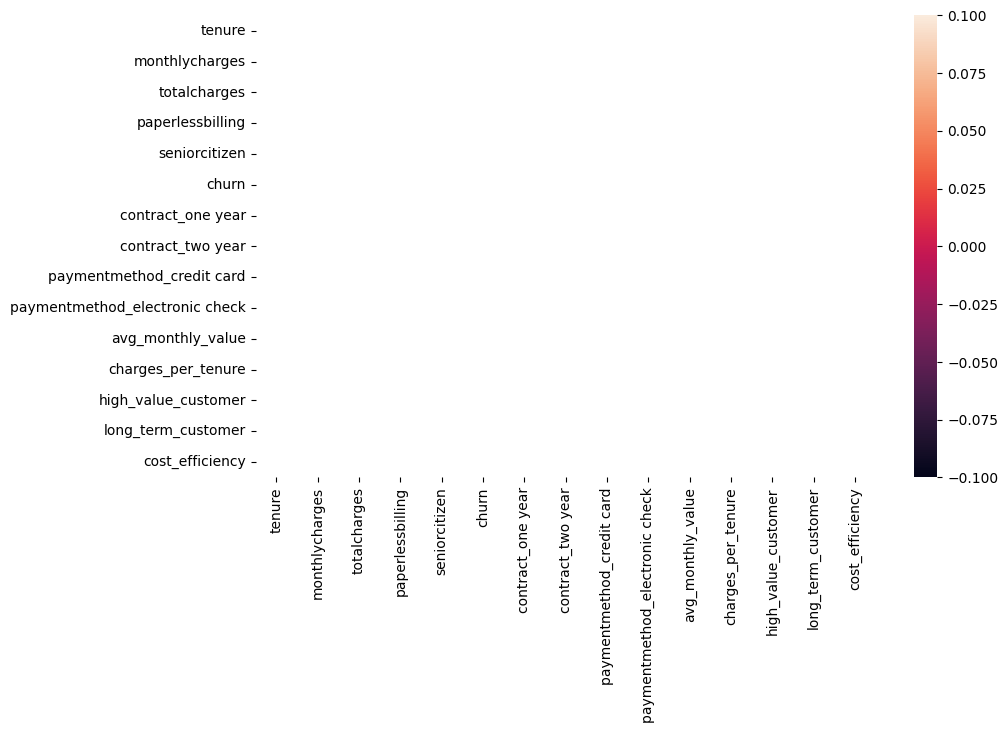

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False)
plt.show()

In [ ]:
df['paperlessbilling'] = df['paperlessbilling'].map({'Yes':1, 'No':0})

In [ ]:
df.rename(columns={'monthly charges': 'monthlycharges'}, inplace=True)

In [ ]:
# Handle missing values
df = df.fillna(0)

# Split data
X = df.drop('churn', axis=1)
y = df['churn']

In [ ]:
# Instead of dropping, fill missing values with 0 or the median
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

In [ ]:
# Convert string to numeric, turning spaces into NaN
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
# Then handle the new NaNs
df = df.dropna(subset=['totalcharges'])

In [ ]:
print(X_train.isnull().sum())

tenure                              0
monthlycharges                      0
totalcharges                        0
paperlessbilling                  400
seniorcitizen                       0
contract_one year                   0
contract_two year                   0
paymentmethod_credit card           0
paymentmethod_electronic check      0
avg_monthly_value                   0
charges_per_tenure                  0
high_value_customer                 0
long_term_customer                  0
cost_efficiency                     0
dtype: int64


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [120]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df.fillna(df.mean(numeric_only=True), inplace=True)

,tenure,monthlycharges,totalcharges,paperlessbilling,seniorcitizen,churn,contract_one year,contract_two year,paymentmethod_credit card,paymentmethod_electronic check,avg_monthly_value,charges_per_tenure,high_value_customer,long_term_customer,cost_efficiency
0,-1.478807,-0.959185,0.176305,NaN,1,0,True,False,True,False,-0.368218,1.418450,0,0,4.319664
1,-0.752287,-0.012290,0.203498,NaN,1,0,False,False,False,True,0.821507,0.009246,0,0,0.206030
2,-0.461679,-1.596890,0.165454,NaN,1,0,False,True,True,False,0.307352,0.737251,0,0,-0.277193
3,0.797622,-1.635539,0.892506,NaN,1,0,False,False,False,True,0.496493,-1.304541,1,0,-1.404329
4,-0.994460,1.379066,0.110303,NaN,1,0,True,False,False,True,19.910505,-1.371426,0,0,0.046364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.652318,0.277576,0.869526,NaN,1,0,False,False,True,False,0.526246,0.181067,1,0,0.680607
496,-1.672545,-1.249051,0.735095,NaN,1,0,False,True,False,False,-1.093005,2.089095,1,0,-2.951582
497,0.458579,1.630283,0.255202,NaN,0,0,False,False,False,False,0.174966,0.747614,0,0,0.097025
498,-1.720980,1.379066,0.714413,NaN,1,1,False,True,True,False,-0.990892,-2.373344,1,0,0.300292


In [121]:
# ==============================
# MODEL PREDICTION
# ==============================
y_pred = model.predict(X_test)

print("✅ Prediction completed!\n")

# ==============================
# EVALUATION METRICS
# ==============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Precision:", precision_score(y_test, y_pred))
print("🔹 Recall:", recall_score(y_test, y_pred))
print("🔹 F1 Score:", f1_score(y_test, y_pred))

print("\n🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ==============================
# CLASSIFICATION REPORT
# ==============================
from sklearn.metrics import classification_report

print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# SAVE PREDICTIONS FILE
# ==============================
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.to_csv("predictions.csv", index=False)

print("\n📁 predictions.csv saved successfully!")

# ==============================
# FEATURE IMPORTANCE (OPTIONAL 🔥)
# ==============================
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)

print("\n🔥 Top Important Features:\n")
print(importance.head(10))

# ==============================
# SAVE IMPORTANT FEATURES
# ==============================
importance.to_csv("feature_importance.csv")

print("\n📁 feature_importance.csv saved!")

# ==============================
# FINAL MESSAGE
# ==============================
print("\n🎯 WEEK 10 PROJECT COMPLETED SUCCESSFULLY ✅")

✅ Prediction completed!

🔹 Accuracy: 0.93
🔹 Precision: 0.9090909090909091
🔹 Recall: 0.625
🔹 F1 Score: 0.7407407407407407

🔹 Confusion Matrix:
 [[83  1]
 [ 6 10]]

🔹 Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        84
           1       0.91      0.62      0.74        16

    accuracy                           0.93       100
   macro avg       0.92      0.81      0.85       100
weighted avg       0.93      0.93      0.92       100


📁 predictions.csv saved successfully!

🔥 Top Important Features:

paymentmethod_electronic check    0.654096
paymentmethod_credit card         0.630590
high_value_customer               0.285816
cost_efficiency                   0.000804
paperlessbilling                  0.000000
long_term_customer                0.000000
avg_monthly_value                -0.014691
totalcharges                     -0.061653
seniorcitizen                    -0.079659
monthlycharges                

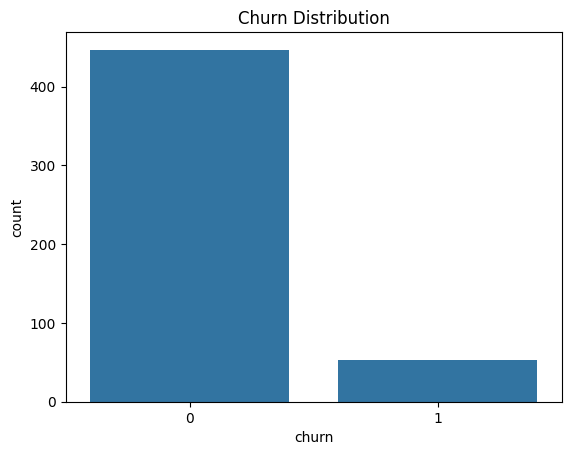

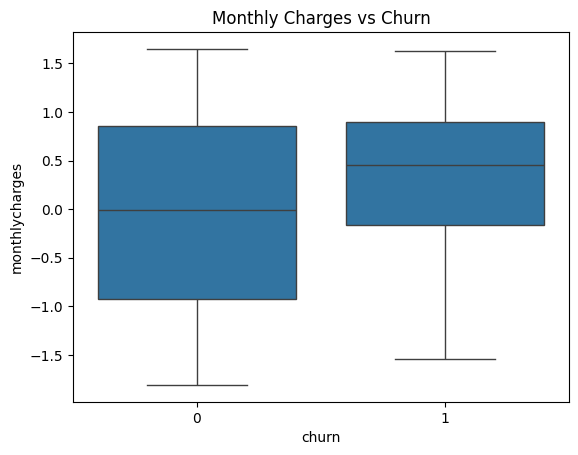

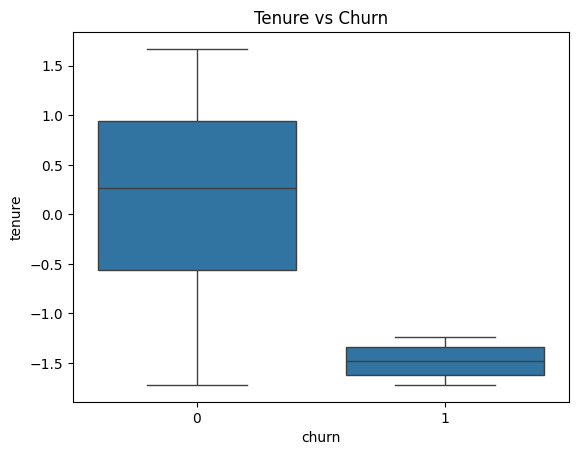

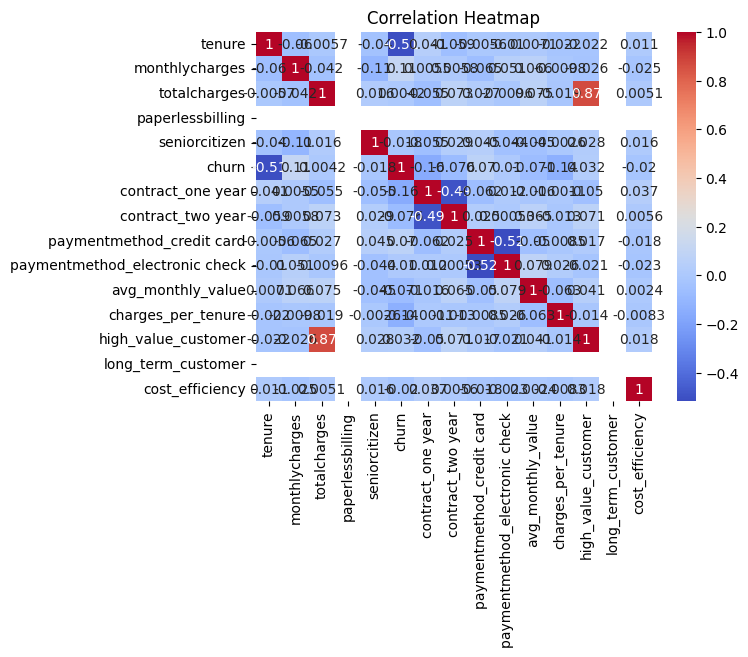

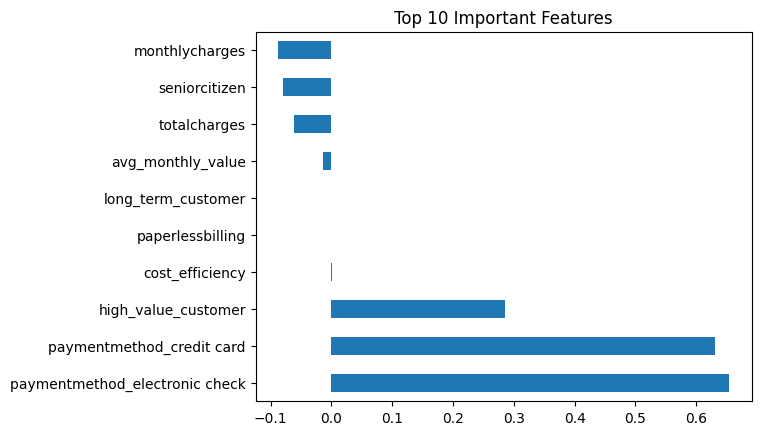

In [122]:
# ==============================
# VISUALIZATION
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Churn Distribution
plt.figure()
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

# 2. Monthly Charges vs Churn
plt.figure()
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# 3. Tenure vs Churn
plt.figure()
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# 4. Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 5. Feature Importance (Top 10)
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure()
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [118]:
# 1. Fill missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# 2. Ensure same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Convert everything to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# 4. Train again (important)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

print("✅ Prediction successful!")

✅ Prediction successful!
